# Laboration 1 - Multi-Armed Bandits
    Course: Reinforcement Learning 4MA903
    Semester: HT24
    Author: Björn Lindenberg
---
## Lab Instructions
* For a completed laboration and a passed grade, every problem must have been sufficiently solved and every question   answered. 
* It is recommended to divide up your definitions and computations, and add any cells you need (both markdown and code). 
* Feel free to organize this notebook in any way that best suits your workflow, this includes moving cells around (even code cells given in problem definitions). However to make grading easier, just make sure to provide explanations, graphs and analysis in headings named **Solution** after each problem definition. Provide math, explanations and arguments in markdown (not in code comments).
* Your overall solution of this laboration should be clearly presented, well-structured and uncluttered. Hence you should remove cells and computations that are irrelevant to your final report. Keep the mindset of presenting a crystal clear report on how to solve each problem.
        

## Introduction
In this laboration we will focus on algorithms for multi-armed bandits. For a fully completed laboration, we will implement simulated environments for the Bernoulli and Gaussian bandit and then solve the decision problems using: **Explore-Then-Commit** (ETC), **Epsilon-greedy** and **Upper-Confidence-Bounds** (UBC). 

### Optimal Action Performance Measure
We recall that a bandit with $K$ arms yields a random reward $R^{(k)}$ for a pull of the $k$:th arm and our goal is to find the arm with the best expectation. That is, our algorithms should ultimately aim to find $$k^* = \text{argmax}_k \mathbb{E}\left[R^{(k)}\right].$$
If we put $\mu_k := \mathbb{E}\left[R^{(k)}\right]$, then the bandit algorithms we consider in this course maintain an estimation $Q^k$ of $\mu_k$ for each step $t$ (in all cases the sample  mean). Thus we could pose the question of how often an algorithm learns $k^*$ at time $t$ by looking at the random variable $X_t$ which converts $\text{argmax}_k Q^k = k^*$ into $1$ if true, otherwise $0$. The expectation of $X_t$ then becomes the percentage of times the algorithm, on average, has found the optimal action at time $t$. The exact expectation may not be fully known, but we'll try to estimate it by averaging over many experiments.  

### Regret Performance Measure
In many settings an algorithm also needs to quickly learn a reasonable policy in a finite amount of time. This maximum time is called the **horizon** and we'll denote it by $T$. One performance measure for querying the performance of an algorithm is then the expectation of the **accumulated sum of rewards**: $$\mathbb{E}\left[\sum_{t=1}^T R_t\right],$$ where the sum can be computed by the random sequence of rewards $$R_1, R_2, \dots, R_T$$ observed by an algorithm. Note that by trying to maximize the expectation we strive for algorithmic **data efficiency**, which points to a fast learner. 

Since the accumulated sum of rewards can become quite large depending on the horizon, we'll use an equivalent performance measure called the **regret**. Specifically, if $\pi$ is the policy dictated by our algorithm and $\mu^*$ is the expectation of the optimal arm. Then we have $$\text{Regret}(T, \pi) = T \mu^* - \mathbb{E}\left[\sum_{t=1}^{T} R_t\right] = \mathbb{E}\left[\sum_{t=1}^T \left(\mu^* - R_t\right)\right],$$
which is just the expected difference between always choosing the optimal arm and the outcome of the algorithm for $T$ steps. In this context we thus strive for a learner which minimizes the regret over horizon $T$. The exact regret of an algorithm may not be fully known (only in a bounded sense), but we'll try to estimate it by running many simulations.

### Abstract Bandit Class
To simplify the procedure of passing different types of bandits to our algorithms, we will enforce a certain structure. This is done by the abstract class in the following cell, which by inheritance will form the skeleton for our later implementations. You don't need to change anything in this cell, but note the comments for the functionality of each method. This functionality should be preserved in derived classes later on. 

In [1]:
from abc import ABC, abstractmethod
import tqdm
import numpy as np
import random


class Bandit(ABC):

    @abstractmethod
    def pull(self, k: int) -> float:
        """Samples a reward from the kth arm"""
        pass

    @property
    @abstractmethod
    def K(self) -> int:
        """Returns the number of arms of the Bandit"""
        pass

---

# Part A - Bandit Environments and ETC

In this section we're going to implement Bernoulli and Gaussian bandit environments and test them with a simple algorithm called *Explore-Then-Commit* (ETC).

## The Bernoulli Bandit 
Recall that a Bernoulli bandit with $K$ arms is fully determined by a vector $(\theta_0, \theta_1, \dots, \theta_{K-1}) \in [0,1]^K$, where a pull on the $k$:th arm generates a reward $R^{(k)} \in \{0,1\}$ drawn from a Bernoulli distribution with parameter $\theta_k$. Explicitly we have $$\text{Pr}(R^{(k)} = 1) = \theta_k, \quad \text{Pr}(R^{(k)} = 0) = 1 - \theta_k.$$
Note that $$ \mathbb{E}\left[R^{(k)}\right] = 1 \cdot \theta_k + 0 \cdot (1 - \theta_k) = \theta_k,$$
hence $\theta_k$ also represents the mean reward of a pull of arm $k$. In particular $\mu^* = \text{max}_k \theta_k$.

___

### Problem 1. `BernoulliBandit` Class
Our first problem is about the actual implementation of an environment for Bernoulli bandits. By completing the following cell, implement a `BernoulliBandit` class which inherits from our abstract `Bandit` class. Feel free to add imports or further functionality. In particular, you will need to reference the comments in the abstract class and find a random number generator (you may return to this class many times depending on your need of functionality).

### Solution:

In [2]:
class BernoulliBandit(Bandit):
    """A BernoulliBandit is created with a list of K floats in [0,1] (thetas).
    The values represent success probabilities for each arm.
    """

    def __init__(self, thetas):
        self.thetas = list(thetas)

    def pull(self, k: int) -> float:
        return 1.0 if random.random() < self.thetas[k] else 0.0

    @property
    def K(self) -> int:
        return len(self.thetas)

___

## Explore-Then-Commit 
The ETC algorithm will be our most basic algorithm in this laboration. Precisely as the name suggests, ETC first goes through an exploring phase, where it gathers data on the different arms. It then commits greedily to always picking what it believes to be the best arm according to the current data until the horizon is met. For the exploring phase we'll simply try each arm a number of times. More precisely, if we fix $m \geq 1$ and let $Q^k(t) $ be the observed mean of the $k$:th arm at time $t$. Then we have the ETC-policy $\pi_m$ for action $A_t$ at time $t$ given by:
$$ A_t = \left \{ \begin{array}{cl} t \ \text{mod} \ K  & 1 \leq t \leq m K, \\ \text{argmax}_k  Q^k(t) & t > m K. \end{array} \right. $$

That is, $\pi_m$ will sample each arm $m$ times and then commit to $\text{argmax}_k  Q^k(t)$ until time $T$. 

---

### Problem 2. `BernoulliBandit` ETC Test
Now we try to solve the 9-armed Bernoulli bandit with parameters $$\theta_k = (k+1)/10, \quad k=0,1,\dots,8,$$ by using ETC. 

Specifically our tasks and analysis questions are the following:
1. Implement ETC in a following cell. To make it more generally applicable to different environments (so we may use it again later), only consider the functionality defined by the abstract class. The function should take a `Bandit` environment, a `horizon` and the ETC-parameter `m`. Feel free to return any objects you require.  
2. With horizon $T=1000$, for each $m$ and each run of ETC and time step $t$, store the random accumulated regret $$\text{Regret}(t, \pi_m) := \sum_{i = 1}^t (\mu^* - R_i) $$ and a float conversion of the Boolean ($\text{argmax}_k  Q^k = k^*$) in two lists of size $T$. Then average these lists over 2000 runs. Note that the averages will firstly be an estimation of regret and secondly the percentage of times the optimal action was chosen at any fixed step $t$. An example of a plot with **bogus data** overlaying curves for different parameters can be seen below.

<div style="text-align: center;">

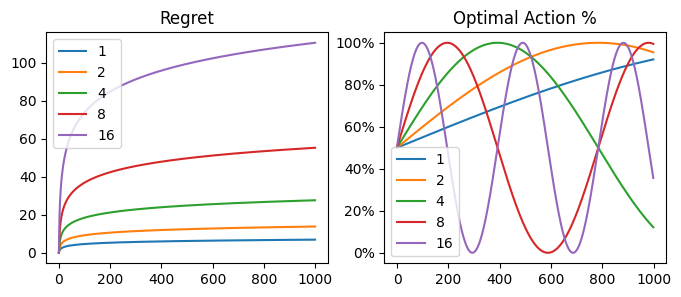

</div>

3. Try to find a value for $m$ which in expectation effectively solves the environment, with the optimal action around 98% or better at $T=1000$, but also with a relatively low expected regret among such algorithms.
4. Looking at the graphs, what's your thoughts about the performance of ETC? Do you think you can explain the curves? How would the curves look like if an algorithm generates a good and fast learner?

In [3]:
def etc(bandit, horizon, m):
    """
    Explore-Then-Commit algorithm.
    
    Parameters
    ----------
    bandit  : Bandit instance with attributes .K (int) and .pull(k) -> float
    horizon : int, total number of pulls T
    m       : int, number of exploration pulls per arm
    
    Returns
    -------
    rewards    : np.ndarray of shape (T,)   rewards R_t actually received
    actions    : np.ndarray of shape (T,)   arm index pulled at each step
    emp_means  : np.ndarray of shape (K,)   empirical mean used to commit
    """
    K = bandit.K
    T = horizon
    rewards = np.empty(T, dtype=float)
    actions = np.empty(T, dtype=int)

    counts = np.zeros(K, dtype=int)
    sums   = np.zeros(K, dtype=float)
    t = 0
    for _ in range(m):
        for k in range(K):
            if t >= T:
                break
            r = bandit.pull(k)
            rewards[t] = r
            actions[t] = int(np.argmax(sums/counts))  # We need to compute optimality by knowing the optimal, not choosing the optimal, hence the action name being wrong!
            counts[k] += 1
            sums[k]   += r
            t += 1

    emp_means = sums / np.maximum(counts, 1)
    best_arm  = int(np.argmax(emp_means))

    while t < T:
        r = bandit.pull(best_arm)
        rewards[t] = r
        actions[t] = int(np.argmax(emp_means))  # Same here as above
        t += 1

    return rewards, actions, emp_means

In [4]:
def run_experiment_bernoulli(bandit_thetas, horizon=1000, m_values=(1, 5, 10, 50, 100),
                   n_runs=2000, seed=0):
    """
    For each m, run ETC n_runs times on a fresh BernoulliBandit with the
    given thetas, and return per-step averaged regret and optimal-action
    indicator.
    """
    K = len(bandit_thetas)
    mu_star = max(bandit_thetas)
    k_star  = int(np.argmax(bandit_thetas))

    results = {}
    for m in tqdm.tqdm(m_values):
        # Accumulators of shape (T,)
        regret_acc = np.zeros(horizon)
        opt_acc    = np.zeros(horizon)

        for run in range(n_runs):
            np.random.seed(seed + run * 1000 + m)
            bandit = BernoulliBandit(bandit_thetas)

            rewards, actions, _ = etc(bandit, horizon, m)

            inst_regret = mu_star - rewards
            regret_acc += np.cumsum(inst_regret)
            opt_acc    += (actions == k_star).astype(float)                         # Correct or not at timestep t
            #opt_acc    += np.cumsum(actions == k_star)/np.arange(1, horizon + 1)    # Fraction of correct choices at timestep t

        results[m] = {
            "avg_regret": regret_acc / n_runs,
            "avg_opt"   : opt_acc    / n_runs,
        }
    return results, mu_star, k_star

### Solution:

  0%|          | 0/7 [00:00<?, ?it/s]C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\2311558366.py:31: RuntimeWarning: invalid value encountered in divide
  actions[t] = int(np.argmax(sums/counts))  # We need to compute optimality by knowing the optimal, not choosing the optimal, hence the action name being wrong!
100%|██████████| 7/7 [00:18<00:00,  2.65s/it]


<Figure size 640x480 with 0 Axes>

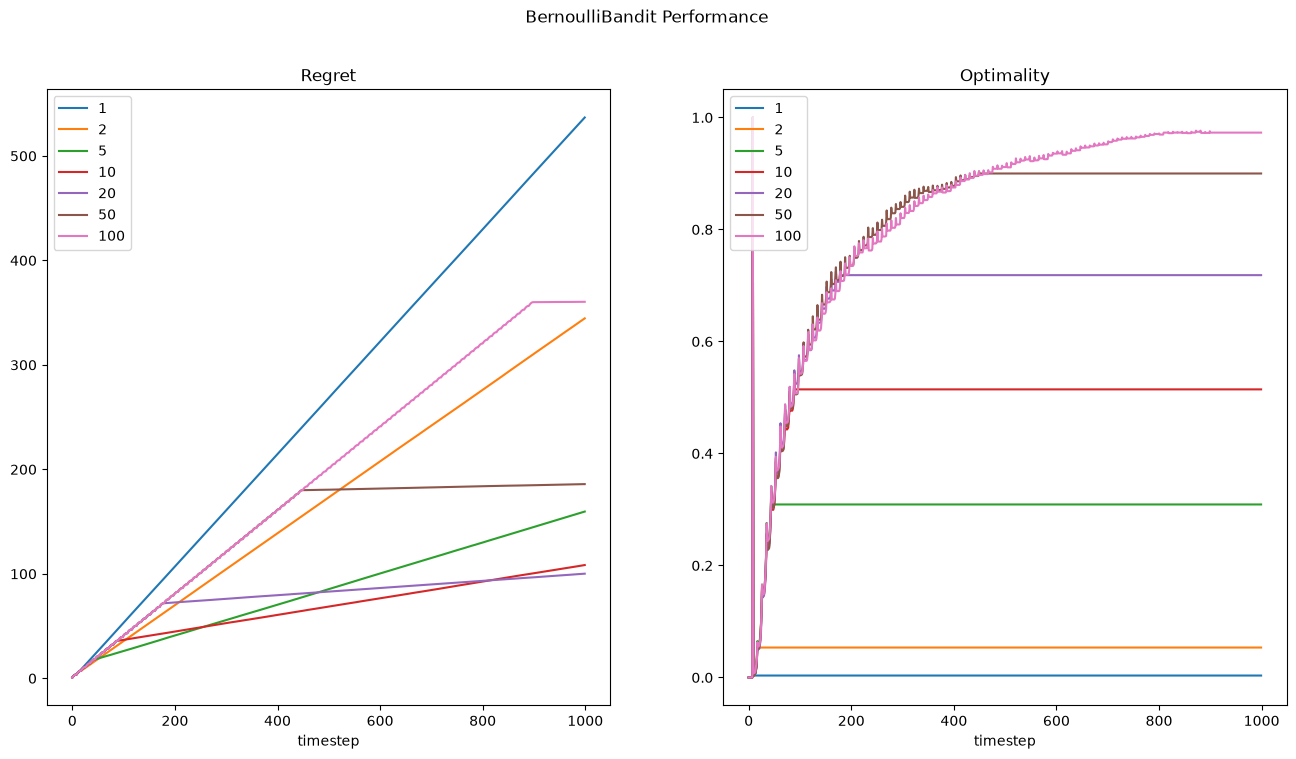

In [5]:
from matplotlib import pyplot as plt

arms = 9
bandit_thetas = [(k+1)/10 for k in range(arms)]
horizon = 1000
m_values = (1, 2, 5, 10, 20, 50, 100)
n_runs = 2000

results, mu_star, k_star = run_experiment_bernoulli(bandit_thetas=bandit_thetas, horizon=horizon, m_values=m_values, n_runs=n_runs)

plt.figure()
fig, axes = plt.subplots(1, 2, figsize=[16, 8])
plt.suptitle("BernoulliBandit Performance")
plt.subplot(1, 2, 1)
plt.title("Regret")
plt.xlabel("timestep")
plt.subplot(1, 2, 2)
plt.title("Optimality")
plt.xlabel("timestep")

for m in results.keys():
    axes[0].plot(np.arange(0, horizon), results[m]["avg_regret"], label=m)
    axes[1].plot(np.arange(0, horizon), results[m]["avg_opt"], label=m)

axes[0].legend()
axes[1].legend()
plt.show()

___

## The Gaussian Bandit
The Gaussian Bandit with $K$ arms is fully determined by vectors $(\mu_0, \mu_1, \dots, \mu_{K-1})$ and $(\sigma_0, \sigma_1, \dots, \sigma_{K-1})$, where the reward $R^{(k)}$ for a pull on the $k$:th arm is distributed as $$ R^{(k)} \sim \mathcal{N}(\mu_k,\sigma_k).$$
It follows that $\mathbb{E}\left[R^{(k)} \right] = \mu_k$ and in particular $\mu^* = \max_k \{\mu_k\}$. Thus, any reward $R$ from a Gaussian Bandit can be seen as $R = \mu + \epsilon$, where $\mu$ is a centered value and $\epsilon$ is a random noise term. A learner needs to eventually see through the noise and pick the arm with the highest expectation.
 

___

### Problem 3. The `GaussianBandit` Class and ETC Test
In this problem we'll repeat much of what we did for the `BernoulliBandit`, but now for a `GaussianBandit`. The bandit we'll consider for an ETC test is the 9-armed Gaussian bandit with 
$$\mu_k = (k+1)/10, \quad \sigma_k = 1/5, \quad k=0,1,\dots,8.$$

**Tasks:**
1. By inheriting from the abstract `Bandit` class, implement a class for Gaussian bandits in a cell below. In particular, you will need to reference the comments in the abstract class and find a generator for normal variates.
2. Repeat tasks (2) and (3) of Problem 2 using your previous implementation of ETC.

In [6]:
class GaussianBandit(Bandit):
    """A GaussianBandit is created with two lists of K floats
    to represent means and standard deviations for the normally
    distributed arms.
    """

    def __init__(self, means, sigmas):
        self.means = list(means)
        self.sigmas = list(sigmas)

    def pull(self, k: int) -> float:
        return random.gauss(self.means[k], self.sigmas[k])

    @property
    def K(self) -> int:
        return len(self.means)

In [7]:
def run_experiment_gaussian(bandit_means, bandit_sigmas, horizon=1000,
                            m_values=(1, 5, 10, 50, 100),
                            n_runs=2000, seed=0):
    """
    For each m, run ETC n_runs times on a fresh GaussianBandit with the
    given means and sigmas, and return per-step averaged regret and
    optimal-action indicator.
    """
    K = len(bandit_means)
    assert len(bandit_sigmas) == K
    mu_star = float(max(bandit_means))
    k_star  = int(np.argmax(bandit_means))

    results = {}
    for m in tqdm.tqdm(m_values):
        regret_acc = np.zeros(horizon)
        opt_acc    = np.zeros(horizon)

        for run in range(n_runs):
            # Fresh RNG per run so results are reproducible
            np.random.seed(seed + run * 1000 + m)
            bandit = GaussianBandit(bandit_means, bandit_sigmas)

            rewards, actions, _ = etc(bandit, horizon, m)

            # Realised instantaneous regret and its cumulative sum
            inst_regret  = mu_star - rewards
            regret_acc  += np.cumsum(inst_regret)
            opt_acc    += (actions == k_star).astype(float)                         # Correct or not at timestep t
            #opt_acc    += np.cumsum(actions == k_star)/np.arange(1, horizon + 1)    # Fraction of correct choices at timestep t

        results[m] = {
            "avg_regret": regret_acc / n_runs,
            "avg_opt"   : opt_acc    / n_runs,
        }
    return results, mu_star, k_star

### Solution

  0%|          | 0/7 [00:00<?, ?it/s]C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\2311558366.py:31: RuntimeWarning: invalid value encountered in divide
  actions[t] = int(np.argmax(sums/counts))  # We need to compute optimality by knowing the optimal, not choosing the optimal, hence the action name being wrong!
100%|██████████| 7/7 [00:18<00:00,  2.67s/it]


<Figure size 640x480 with 0 Axes>

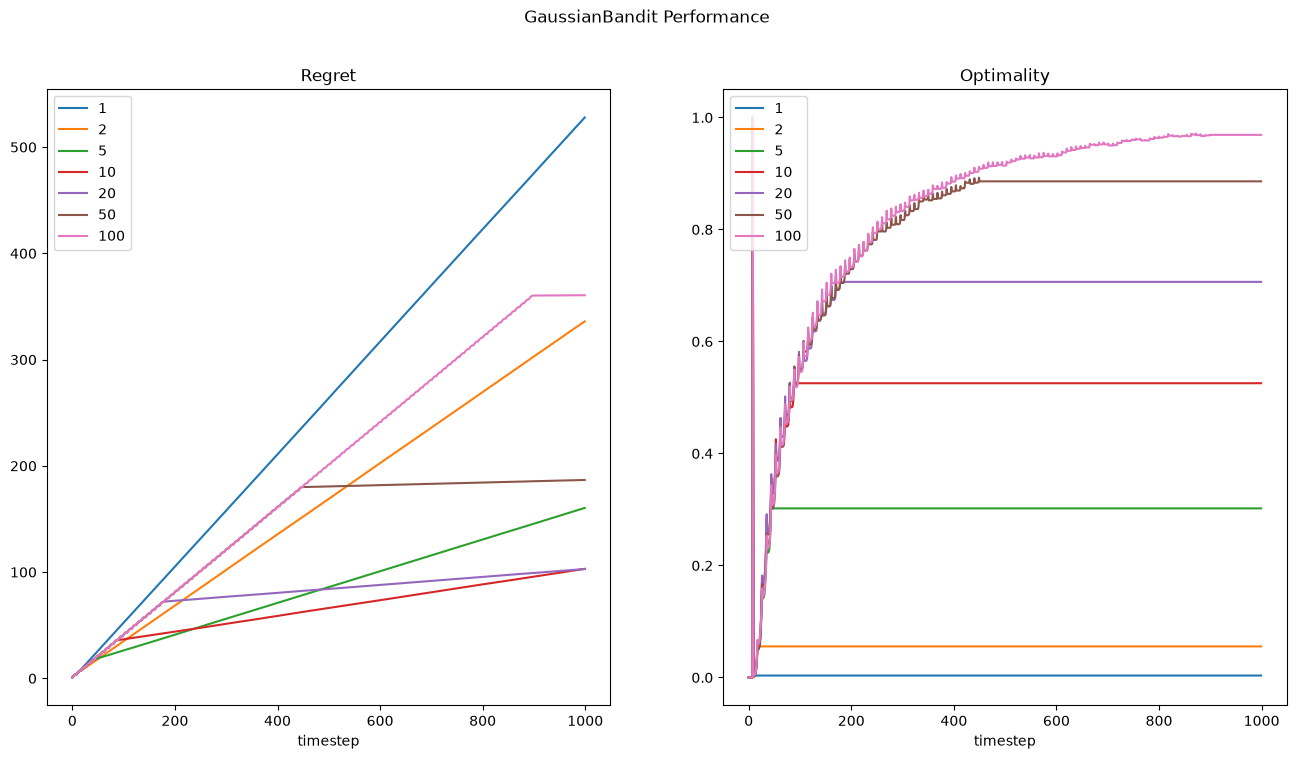

In [8]:
arms = 9
bandit_means = [(k+1)/10 for k in range(arms)]
bandit_sigmas = [1/5 for k in range(arms)]
horizon = 1000
m_values = (1, 2, 5, 10, 20, 50, 100)
n_runs = 2000

results, mu_star, k_star = run_experiment_bernoulli(bandit_thetas=bandit_thetas, horizon=horizon, m_values=m_values, n_runs=n_runs)

plt.figure()
fig, axes = plt.subplots(1, 2, figsize=[16, 8])
plt.suptitle("GaussianBandit Performance")
plt.subplot(1, 2, 1)
plt.title("Regret")
plt.xlabel("timestep")
plt.subplot(1, 2, 2)
plt.title("Optimality")
plt.xlabel("timestep")

for m in results.keys():
    axes[0].plot(np.arange(0, horizon), results[m]["avg_regret"], label=m)
    axes[1].plot(np.arange(0, horizon), results[m]["avg_opt"], label=m)

axes[0].legend()
axes[1].legend()
plt.show()

---

# Part B - Improved Algorithms
In this section we'll consider slightly more sophisticated algorithms. Namely, the **$\epsilon$-greedy** method and the **UCB** method.

## The $\epsilon$-greedy Algorithm
The term *greedy* can be said to come from choosing an action that seems best in the short term. Whereas *epsilon* comes from the name of the parameter that signifies our willingness to explore. More precisely, the $\epsilon$-greedy policy $\pi_\epsilon$ maintains at all steps $t$ a parameter $\epsilon_t$, which dictates the probability for us to do *exploration* versus *exploiting* the current data. Here $\epsilon_t$ may change with time or remain fixed, although the method is *non-adaptive* in the sense that the exploration schedule is independent of observations. Specifically, if we let  $Q^k$ be the observed mean of the $k$:th arm and we're given an exploration schedule 
$$\epsilon_0, \epsilon_1, \dots, \epsilon_t, \dots, $$
then we obtain the policy $\pi_\epsilon$ by
$$ A_t = \left \{ \begin{array}{cl} k \sim \mathcal{U}\{0,1, \dots, K-1\}  & \text{with probability } \epsilon_t, \\ \text{argmax}_k Q^k  & \text{with probability } 1 - \epsilon_t. \end{array} \right. $$
In words: at all steps $t$, $\pi_\epsilon$ picks a random action with probability $\epsilon_t$ otherwise it takes the greedy action to exploit the observed data. Hence exploration can now be said to be spread over time compared to ETC.  

___

### Problem 4. Solving Bandits with $\epsilon$-greedy
In this problem we'll try to solve the 9-armed environments defined previously, but here with $\epsilon$-greedy schedules. Thus, we consider the `BernoulliBandit` with $R^{(k)} \sim \text{Bernoulli}\left(\frac{k+1}{10}\right)$ and the `GaussianBandit` with $R^{(k)} \sim \mathcal{N}\left(\frac{k+1}{10}, \frac{1}{5}\right)$, and for each experiment we use $T = 1000$ and $2000$ different runs. 

Our tasks are the following:
1. Implement $\epsilon$-greedy in a cell below. The function should take a `Bandit` object, the maximum `horizon` and a `Callable` for our $\epsilon_t$-schedule. **Hint:** You can implement `epsilon` with a lambda or any function that takes the step $t$ as an argument and returns $\epsilon_t$. Then simply pass the `Callable` object as the argument. For example 
    ```
    epsilon = lambda _: 0.1
    ``` 
    represents a fixed schedule `epsilon` with $\epsilon_t = 0.1$ for all $t$.    
2. Solve the `BernoulliBandit` by using a fixed schedule. That is, $\forall t \ \epsilon_t := \epsilon \in (0,1)$. By comparing different $\epsilon$ and as the previous problems, try to dial in on a value that reaches 98% optimal action with lowest regret at $T = 1000$ over $2000$ runs.
3. Another common approach is to have a decaying schedule such that $\epsilon_t := \tau^t$ for some $\tau \in (0,1)$. The idea is to have more exploration earlier on (with $\tau$ reasonably close to 1), but then take more exploitative decisions as our uncertainty about the environment gets smaller (since $\epsilon_t \to 0$ as $t \to \infty$). Thus, $\tau$ is a hyperparameter that dictates how fast we want to go from mostly exploration into mostly exploitation. For the `BernoulliBandit`, find a $\tau$-value that beats your best fixed schedule in (2) in terms of regret given the 98% optimal action threshold. Present and compare the algorithms with regret and optimal action curves. 
4. Repeat (2) and (3) for the `GaussianBandit`. 
5. Which environment seems easier for simultaneous optimization of both regret and optimal action. Any thoughts on why?


In [9]:
# Your epsilon-greedy algorithm
from typing import Callable


def eps_greedy(env: Bandit, horizon: int, epsilon: Callable[[int], float]):
    """
    Epsilon-greedy algorithm.
    """
    K = env.K
    T = horizon

    rewards = np.empty(T, dtype=float)
    actions = np.empty(T, dtype=int)
    counts = np.zeros(K, dtype=int)
    sums   = np.zeros(K, dtype=float)

    for t in range(T):
        if np.random.random() < epsilon(t):
            k = int(np.random.randint(K))          # explore uniformly
        else:
            k = int(np.argmax(sums / counts))      # exploit greedy

        r = env.pull(k)
        rewards[t] = r
        actions[t] = int(np.argmax(sums / counts))
        counts[k] += 1
        sums[k]   += r

    emp_means = sums / np.maximum(counts, 1)
    return rewards, actions, emp_means

In [10]:
def run_experiment_eps(bandit_factory, horizon=1000, epsilons=None,
                       n_runs=2000, seed=0, mu_star=None, k_star=None):
    """
    For each epsilon schedule in `epsilons` (a dict {label: Callable}),
    run eps_greedy n_runs times on a fresh bandit and return per-step
    averaged regret and optimal-action indicator.
    """
    if epsilons is None:
        epsilons = {
            "eps=0.01":  lambda _: 0.01,
            "eps=0.05":  lambda _: 0.05,
            "eps=0.1":   lambda _: 0.1,
            "tau=0.9":   lambda t: 0.9 ** t,
            "tau=0.99":  lambda t: 0.99 ** t,
            "tau=0.999": lambda t: 0.999 ** t,
        }

    results = {}
    for label, eps in epsilons.items():
        regret_acc = np.zeros(horizon)
        opt_acc    = np.zeros(horizon)

        for run in tqdm.tqdm(range(n_runs), desc=label):
            np.random.seed(seed + run)
            env = bandit_factory()
            rewards, actions, _ = eps_greedy(env, horizon, eps)

            regret_acc += np.cumsum(mu_star - rewards)
            opt_acc    += (actions == k_star).astype(float)                         # Correct or not at timestep t
            #opt_acc    += np.cumsum(actions == k_star)/np.arange(1, horizon + 1)    # Fraction of correct choices at timestep t

        results[label] = {
            "avg_regret": regret_acc / n_runs,
            "avg_opt"   : opt_acc    / n_runs,
        }
    return results

### Solution

eps=0.01:   0%|          | 0/2000 [00:00<?, ?it/s]C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\442870865.py:21: RuntimeWarning: invalid value encountered in divide
  k = int(np.argmax(sums / counts))      # exploit greedy
C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\442870865.py:25: RuntimeWarning: invalid value encountered in divide
  actions[t] = int(np.argmax(sums / counts))
eps=0.2: 100%|██████████| 2000/2000 [00:07<00:00, 257.48it/s]


<Figure size 640x480 with 0 Axes>

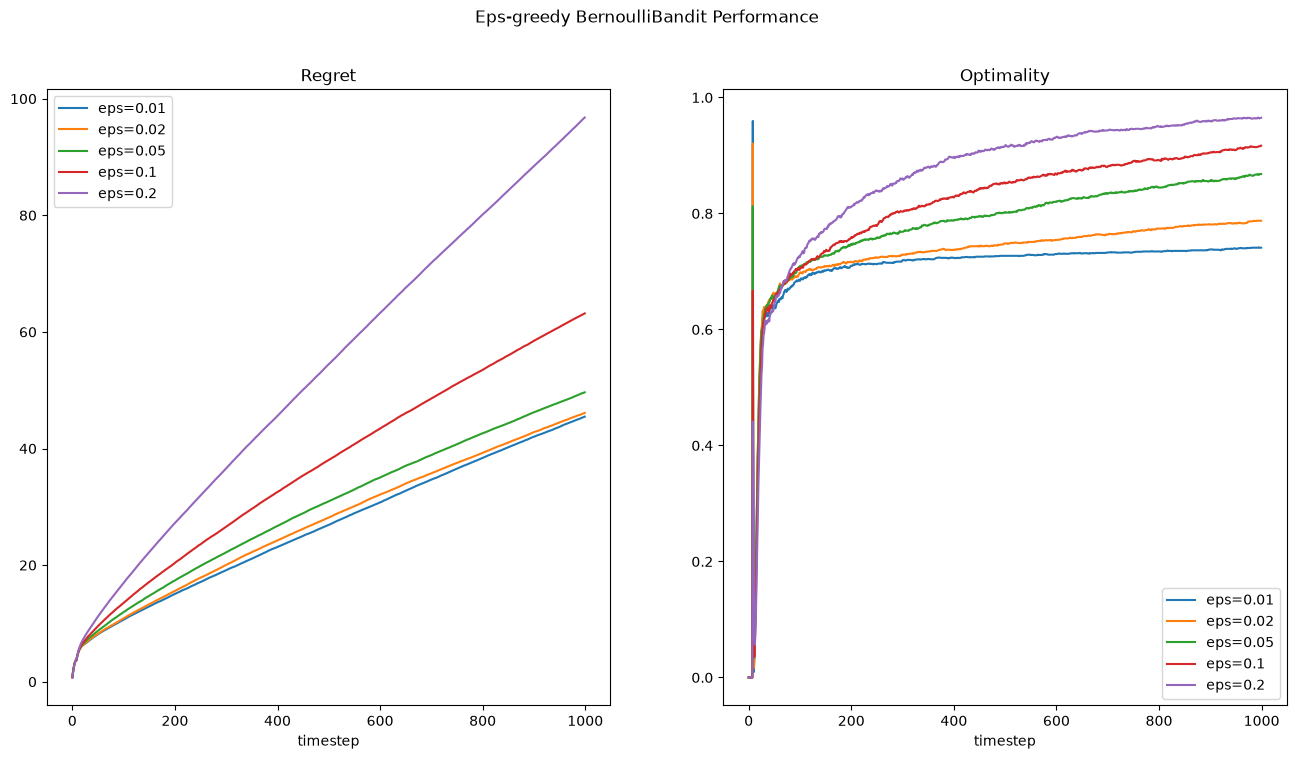

In [11]:
# Fixed Epsilon-greedy BernoulliBandit...

arms = 9
horizon = 1000
n_runs = 2000

bernoulli_thetas = [(k + 1) / 10 for k in range(arms)]
bernoulli_factory = lambda: BernoulliBandit(bernoulli_thetas)
mu_star = max(bernoulli_thetas)
k_star  = int(np.argmax(bernoulli_thetas))

eps_fixed = {
    "eps=0.01": lambda _: 0.01,
    "eps=0.02": lambda _: 0.02,
    "eps=0.05": lambda _: 0.05,
    "eps=0.1":  lambda _: 0.1,
    "eps=0.2":  lambda _: 0.2,
}

results = run_experiment_eps(bernoulli_factory, horizon=horizon, epsilons=eps_fixed, n_runs=n_runs, seed=0, mu_star=mu_star, k_star=k_star)

plt.figure()
fig, axes = plt.subplots(1, 2, figsize=[16, 8])
plt.suptitle("Eps-greedy BernoulliBandit Performance")
plt.subplot(1, 2, 1)
plt.title("Regret")
plt.xlabel("timestep")
plt.subplot(1, 2, 2)
plt.title("Optimality")
plt.xlabel("timestep")

for label in results.keys():
    axes[0].plot(np.arange(0, horizon), results[label]["avg_regret"], label=label)
    axes[1].plot(np.arange(0, horizon), results[label]["avg_opt"], label=label)

axes[0].legend()
axes[1].legend()
plt.show()

tau=0.95:   0%|          | 0/2000 [00:00<?, ?it/s]C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\442870865.py:25: RuntimeWarning: invalid value encountered in divide
  actions[t] = int(np.argmax(sums / counts))
C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\442870865.py:21: RuntimeWarning: invalid value encountered in divide
  k = int(np.argmax(sums / counts))      # exploit greedy
tau=0.9995: 100%|██████████| 2000/2000 [00:07<00:00, 252.29it/s]


<Figure size 640x480 with 0 Axes>

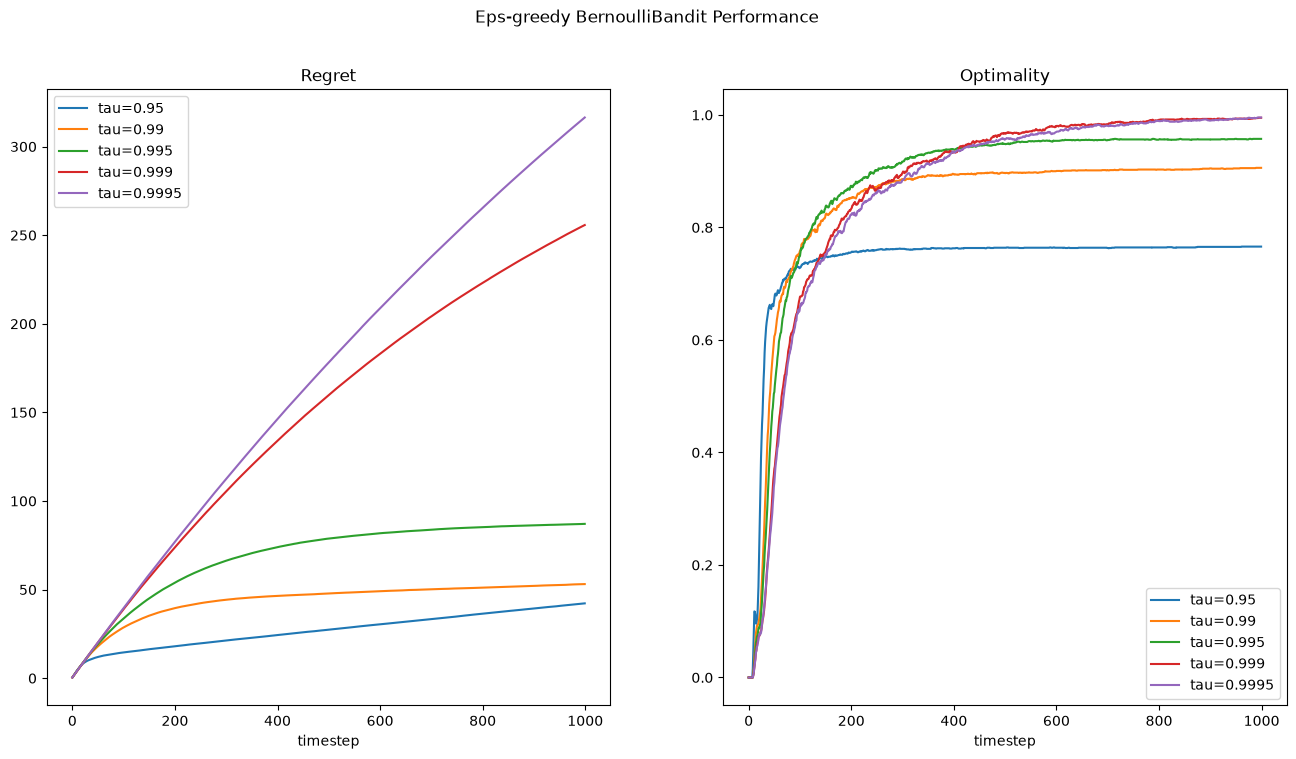

In [12]:
# Decaying Epsilon-greedy BernoulliBandit...

eps_decay = {
    "tau=0.95":   lambda t: 0.95 ** t,
    "tau=0.99":   lambda t: 0.99 ** t,
    "tau=0.995":  lambda t: 0.995 ** t,
    "tau=0.999":  lambda t: 0.999 ** t,
    "tau=0.9995": lambda t: 0.9995 ** t,
}

results = run_experiment_eps(bernoulli_factory, horizon=horizon, epsilons=eps_decay, n_runs=n_runs, seed=0, mu_star=mu_star, k_star=k_star)

plt.figure()
fig, axes = plt.subplots(1, 2, figsize=[16, 8])
plt.suptitle("Eps-greedy BernoulliBandit Performance")
plt.subplot(1, 2, 1)
plt.title("Regret")
plt.xlabel("timestep")
plt.subplot(1, 2, 2)
plt.title("Optimality")
plt.xlabel("timestep")

for label in results.keys():
    axes[0].plot(np.arange(0, horizon), results[label]["avg_regret"], label=label)
    axes[1].plot(np.arange(0, horizon), results[label]["avg_opt"], label=label)

axes[0].legend()
axes[1].legend()
plt.show()

eps=0.01:   0%|          | 0/2000 [00:00<?, ?it/s]C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\442870865.py:21: RuntimeWarning: invalid value encountered in divide
  k = int(np.argmax(sums / counts))      # exploit greedy
C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\442870865.py:25: RuntimeWarning: invalid value encountered in divide
  actions[t] = int(np.argmax(sums / counts))
eps=0.2: 100%|██████████| 2000/2000 [00:08<00:00, 246.05it/s]


<Figure size 640x480 with 0 Axes>

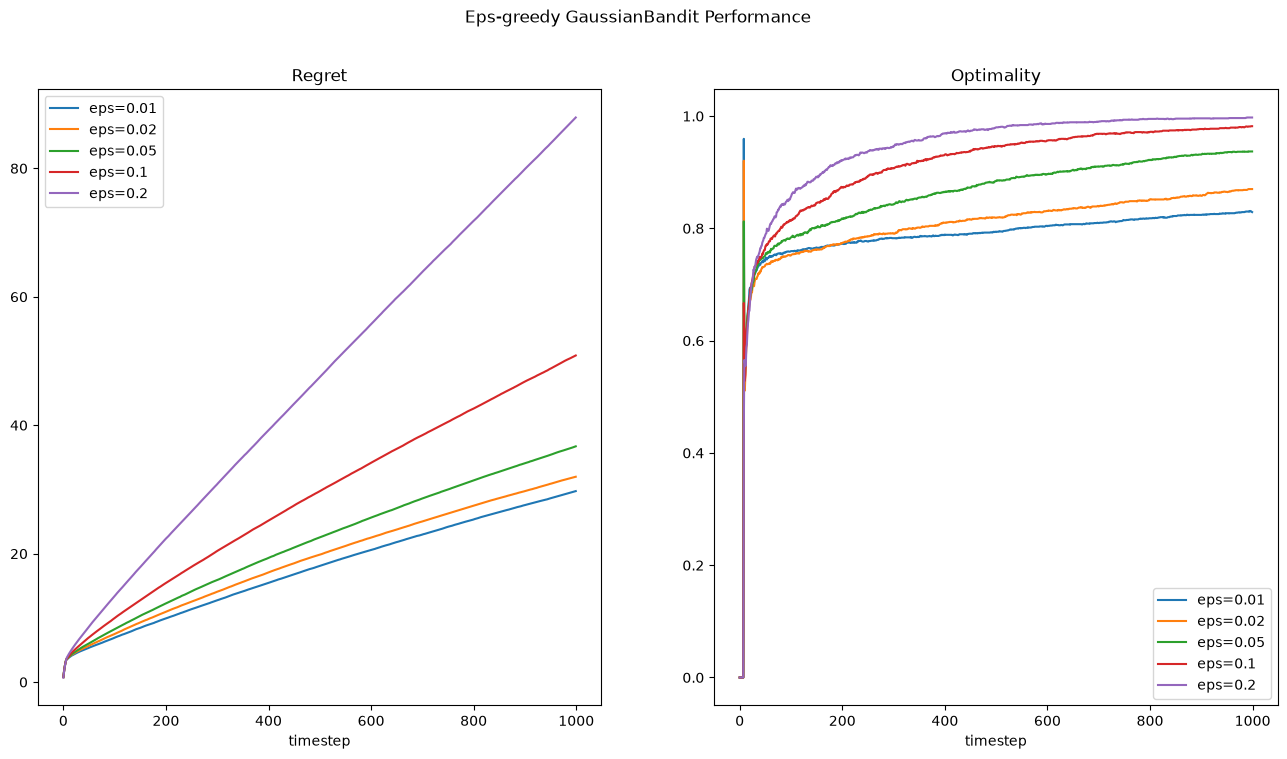

In [13]:
# Fixed Epsilon-greedy GaussianBandit...

gaussian_means = [(k + 1) / 10 for k in range(arms)]
gaussian_sigmas = [1/5 for k in range(arms)]
gaussian_factory = lambda: GaussianBandit(gaussian_means, gaussian_sigmas)

eps_fixed = {
    "eps=0.01": lambda _: 0.01,
    "eps=0.02": lambda _: 0.02,
    "eps=0.05": lambda _: 0.05,
    "eps=0.1":  lambda _: 0.1,
    "eps=0.2":  lambda _: 0.2,
}

results = run_experiment_eps(gaussian_factory, horizon=horizon, epsilons=eps_fixed, n_runs=n_runs, seed=0, mu_star=mu_star, k_star=k_star)

plt.figure()
fig, axes = plt.subplots(1, 2, figsize=[16, 8])
plt.suptitle("Eps-greedy GaussianBandit Performance")
plt.subplot(1, 2, 1)
plt.title("Regret")
plt.xlabel("timestep")
plt.subplot(1, 2, 2)
plt.title("Optimality")
plt.xlabel("timestep")

for label in results.keys():
    axes[0].plot(np.arange(0, horizon), results[label]["avg_regret"], label=label)
    axes[1].plot(np.arange(0, horizon), results[label]["avg_opt"], label=label)

axes[0].legend()
axes[1].legend()
plt.show()

tau=0.95:   0%|          | 0/2000 [00:00<?, ?it/s]C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\442870865.py:25: RuntimeWarning: invalid value encountered in divide
  actions[t] = int(np.argmax(sums / counts))
C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\442870865.py:21: RuntimeWarning: invalid value encountered in divide
  k = int(np.argmax(sums / counts))      # exploit greedy
tau=0.9995: 100%|██████████| 2000/2000 [00:08<00:00, 240.16it/s]


<Figure size 640x480 with 0 Axes>

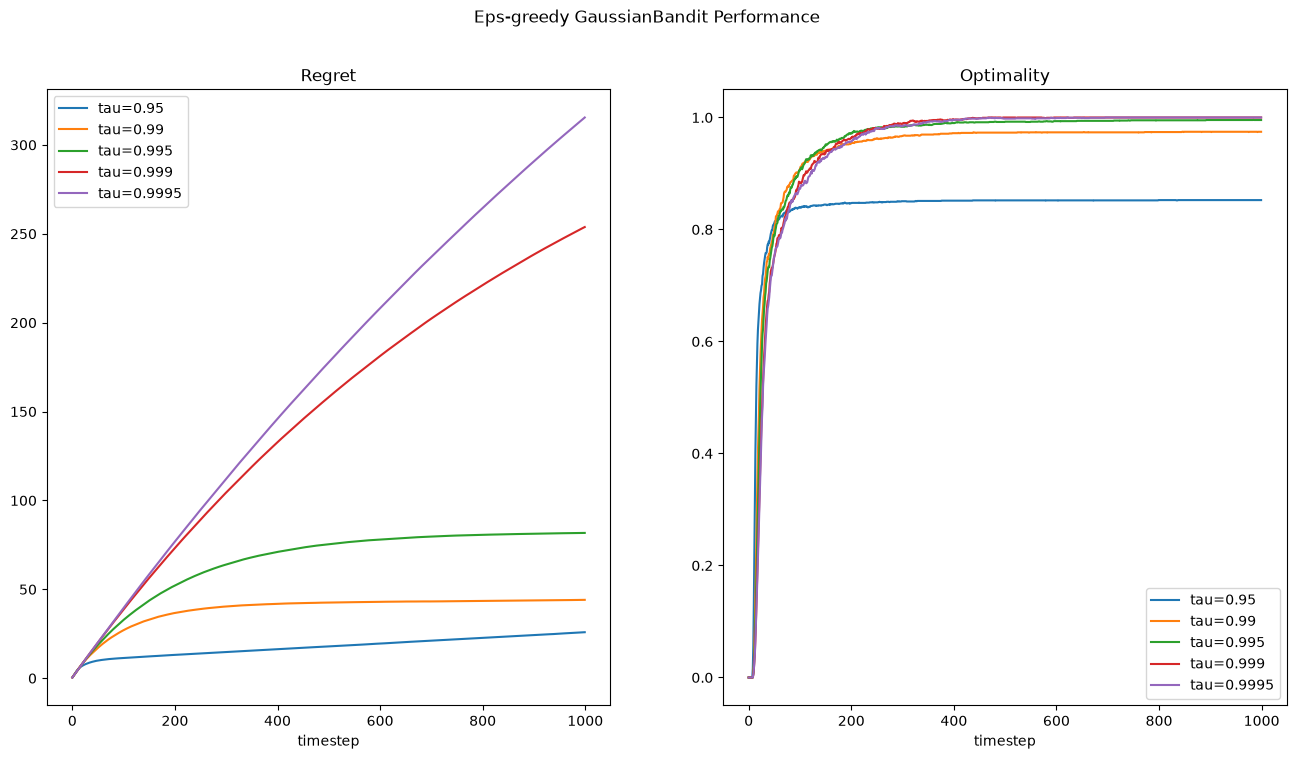

In [14]:
# Decaying Epsilon-greedy GaussianBandit...

gaussian_means = [(k + 1) / 10 for k in range(arms)]
gaussian_sigmas = [1/5 for k in range(arms)]
gaussian_factory = lambda: GaussianBandit(gaussian_means, gaussian_sigmas)

eps_decay = {
    "tau=0.95":   lambda t: 0.95 ** t,
    "tau=0.99":   lambda t: 0.99 ** t,
    "tau=0.995":  lambda t: 0.995 ** t,
    "tau=0.999":  lambda t: 0.999 ** t,
    "tau=0.9995": lambda t: 0.9995 ** t,
}

results = run_experiment_eps(gaussian_factory, horizon=horizon, epsilons=eps_decay, n_runs=n_runs, seed=0, mu_star=mu_star, k_star=k_star)

plt.figure()
fig, axes = plt.subplots(1, 2, figsize=[16, 8])
plt.suptitle("Eps-greedy GaussianBandit Performance")
plt.subplot(1, 2, 1)
plt.title("Regret")
plt.xlabel("timestep")
plt.subplot(1, 2, 2)
plt.title("Optimality")
plt.xlabel("timestep")

for label in results.keys():
    axes[0].plot(np.arange(0, horizon), results[label]["avg_regret"], label=label)
    axes[1].plot(np.arange(0, horizon), results[label]["avg_opt"], label=label)

axes[0].legend()
axes[1].legend()
plt.show()

___

## Upper Confidence Bounds
The next algorithm we'll consider is UCB. The policy derived from it can be said to be *adaptive* to observed data and follows the principle of *optimism in the face of uncertainty*. Instead of choosing an arm greedily w.r.t. our current estimations of the means, we maintain upper confidence bounds dependent on the number of times we've tried each arm and choose actions with an optimistic outlook given any uncertainties of the true means. Explicitly, if $Q^k$ is the observed mean of the $k$:th arm and $r_k(t)$ is a measure of uncertainty at time $t$. Then we choose greedily according to 
$$\text{UCB}_k(t) := Q^k + r_k(t).$$
Here $r_k(t)$ may take different forms, depending on what we want to achieve and our belief about the supposed family of the bandit. If we put $n_k(t)$ as the number of times arm $k$ has been sampled at time $t$, then a common choice is to fix some real parameter $c$ and define 
$$r_k(t) := c \sqrt{\frac{\log t}{n_k(t)}}. $$
Note that $r_k(t)$ gets smaller as the number of samples of the $k$:th arm increases, while it slowly increases if the arm remains relatively unexplored. Thus the value presented by $\text{UCB}_k(t)$ becomes an optimistic view of the expectation given our uncertainty of the true mean $\mu_k$ for arm $k$. We also note that if $n_k(t) = 0$ then $\text{UCB}_k(t) = \infty$, hence our uncertainty about action $k$ is maximized. This effectively leads to an algorithm that samples each arm once at the start of the algorithm. Specifically we may then define a UCB policy by 
$$ A_t = \left \{ \begin{array}{cl} t \mod K  & 1 \leq t \leq K, \\ \text{argmax}_k \left(Q^k+ c \sqrt{\frac{\log t}{n_k}}\right)  & \text t > K, \end{array} \right. $$
which is the one we'll be using in this laboration.  

___

### Problem 5. Solving Bandits with UCB

In this problem we'll continue with the two bandits in Problem 5 and try to solve them with UCB. 

Our tasks are the following:
1. Implement UCB in a cell below. The function should take a `Bandit` environment, a `horizon` and a scaling factor `c` for the added UCB-confidence term.
2. Solve the `BernoulliBandit` by trying out different `c`, and try to dial in on a good value that effectively solves the environment with optimal action threshold 98% and has relatively low expected regret at $T = 1000$. 
3. Repeat (2) for the `GaussianBandit`.

In [29]:
# Your UCB algorithm
def ucb(env: Bandit, horizon: int, c: float):
    """
    UCB-style algorithm.
    """
    K = env.K
    T = horizon

    rewards = np.empty(T, dtype=float)
    actions = np.empty(T, dtype=int)

    counts = np.zeros(K, dtype=int)
    sums   = np.zeros(K, dtype=float)

    for t in range(T):
        if t < K:
            k = t
        else:
            means = sums / counts
            upper = c * np.sqrt(np.log(t) / counts)
            k = int(np.argmax(means + upper))

        r = env.pull(k)
        rewards[t] = r
        actions[t] = int(np.argmax(sums / counts - c * np.sqrt(np.log(t) / counts)))
        counts[k] += 1
        sums[k]   += r

    emp_means = sums / counts
    return rewards, actions, emp_means

In [30]:
def run_experiment_ucb(bandit_factory, horizon=1000, cs=None,
                       n_runs=2000, seed=0, mu_star=None, k_star=None):
    if cs is None:
        cs = {"c=0.5": 0.5, "c=1": 1.0, "c=sqrt2": np.sqrt(2),
              "c=2": 2.0, "c=5": 5.0}

    results = {}
    for label, c in cs.items():
        regret_acc = np.zeros(horizon)
        opt_acc    = np.zeros(horizon)

        for run in tqdm.tqdm(range(n_runs), desc=label):
            np.random.seed(seed + run)
            env = bandit_factory()
            rewards, actions, _ = ucb(env, horizon, c)

            regret_acc += np.cumsum(mu_star - rewards)
            opt_acc    += (actions == k_star).astype(float)

        results[label] = {
            "avg_regret": regret_acc / n_runs,
            "avg_opt"   : opt_acc    / n_runs,
        }
    return results

### Solution

c=0.01:   0%|          | 0/2000 [00:00<?, ?it/s]C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\2963313429.py:25: RuntimeWarning: invalid value encountered in divide
  actions[t] = int(np.argmax(sums / counts - c * np.sqrt(np.log(t) / counts)))
C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\2963313429.py:25: RuntimeWarning: divide by zero encountered in log
  actions[t] = int(np.argmax(sums / counts - c * np.sqrt(np.log(t) / counts)))
C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\2963313429.py:25: RuntimeWarning: invalid value encountered in sqrt
  actions[t] = int(np.argmax(sums / counts - c * np.sqrt(np.log(t) / counts)))
C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\2963313429.py:25: RuntimeWarning: divide by zero encountered in divide
  actions[t] = int(np.argmax(sums / counts - c * np.sqrt(np.log(t) / counts)))
c=√2: 100%|██████████| 2000/2000 [00:17<00:00, 111.78it/s]


<Figure size 640x480 with 0 Axes>

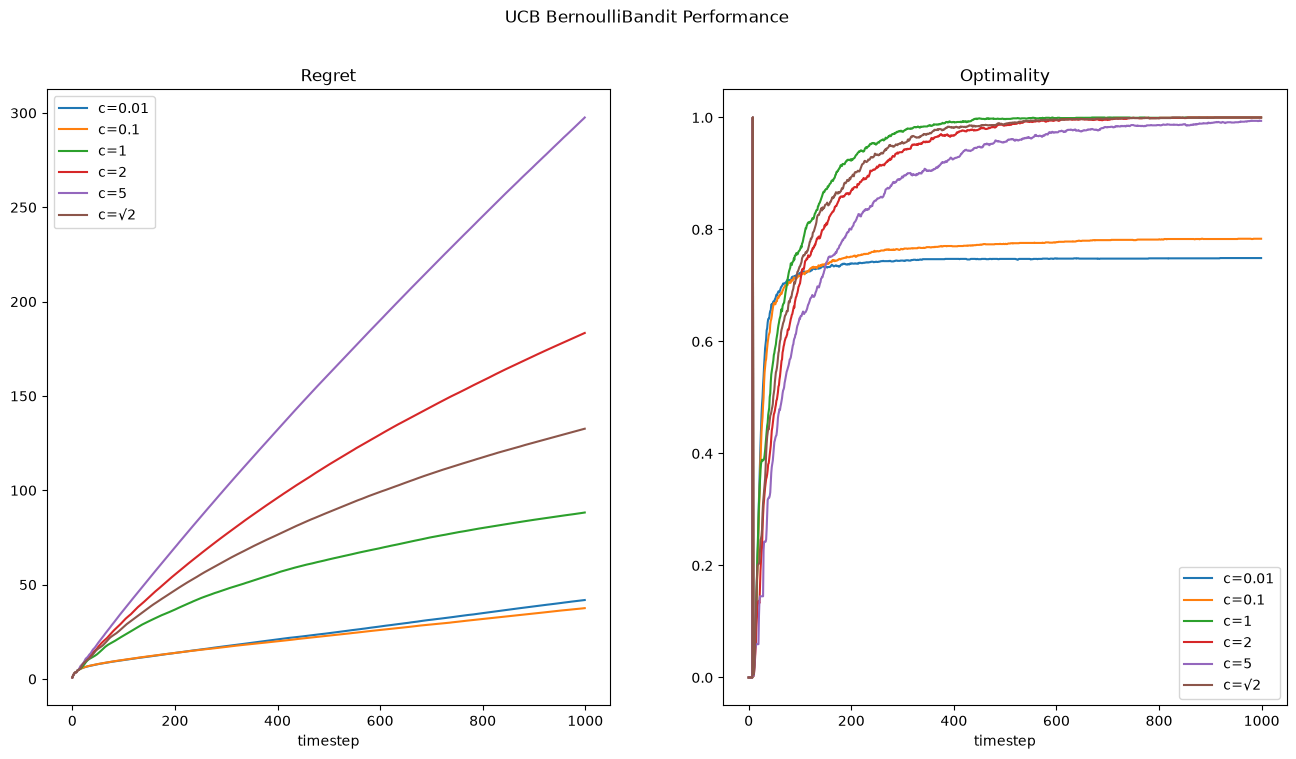

In [31]:
# UCB BernoulliBandit...

arms = 9
horizon = 1000
n_runs = 2000

bernoulli_thetas = [(k + 1) / 10 for k in range(arms)]
bernoulli_factory = lambda: BernoulliBandit(bernoulli_thetas)
mu_star = max(bernoulli_thetas)
k_star  = int(np.argmax(bernoulli_thetas))

cs = {
    "c=0.01":   0.01,
    "c=0.1":    0.1,
    "c=1":      1,
    "c=2":      2,
    "c=5":      5,
    "c=√2":   np.sqrt(2),
}

results = run_experiment_ucb(bernoulli_factory, horizon=horizon, cs=cs, n_runs=n_runs, seed=0, mu_star=mu_star, k_star=k_star)

plt.figure()
fig, axes = plt.subplots(1, 2, figsize=[16, 8])
plt.suptitle("UCB BernoulliBandit Performance")
plt.subplot(1, 2, 1)
plt.title("Regret")
plt.xlabel("timestep")
plt.subplot(1, 2, 2)
plt.title("Optimality")
plt.xlabel("timestep")

for label in results.keys():
    axes[0].plot(np.arange(0, horizon), results[label]["avg_regret"], label=label)
    axes[1].plot(np.arange(0, horizon), results[label]["avg_opt"], label=label)

axes[0].legend()
axes[1].legend()
plt.show()

c=0.01:   0%|          | 0/2000 [00:00<?, ?it/s]C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\2963313429.py:25: RuntimeWarning: invalid value encountered in divide
  actions[t] = int(np.argmax(sums / counts - c * np.sqrt(np.log(t) / counts)))
C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\2963313429.py:25: RuntimeWarning: divide by zero encountered in log
  actions[t] = int(np.argmax(sums / counts - c * np.sqrt(np.log(t) / counts)))
C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\2963313429.py:25: RuntimeWarning: invalid value encountered in sqrt
  actions[t] = int(np.argmax(sums / counts - c * np.sqrt(np.log(t) / counts)))
C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\2963313429.py:25: RuntimeWarning: divide by zero encountered in divide
  actions[t] = int(np.argmax(sums / counts - c * np.sqrt(np.log(t) / counts)))
c=√2: 100%|██████████| 2000/2000 [00:19<00:00, 100.12it/s]


<Figure size 640x480 with 0 Axes>

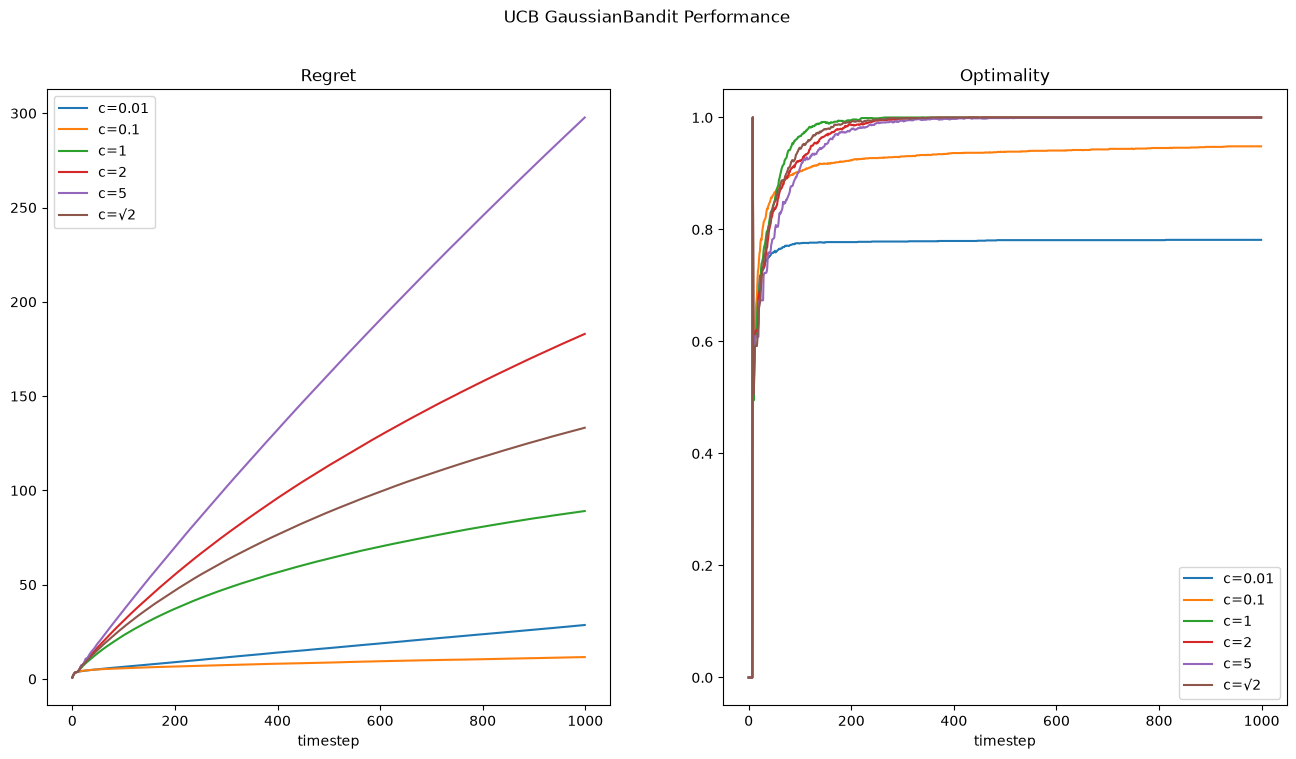

In [32]:
# UCB GaussianBandit...
gaussian_means = [(k + 1) / 10 for k in range(arms)]
gaussian_sigmas = [1/5 for k in range(arms)]
gaussian_factory = lambda: GaussianBandit(gaussian_means, gaussian_sigmas)
mu_star = max(gaussian_means)
k_star  = int(np.argmax(gaussian_means))

cs = {
    "c=0.01":   0.01,
    "c=0.1":    0.1,
    "c=1":      1,
    "c=2":      2,
    "c=5":      5,
    "c=√2":   np.sqrt(2),
}

results = run_experiment_ucb(gaussian_factory, horizon=horizon, cs=cs, n_runs=n_runs, seed=0, mu_star=mu_star, k_star=k_star)

plt.figure()
fig, axes = plt.subplots(1, 2, figsize=[16, 8])
plt.suptitle("UCB GaussianBandit Performance")
plt.subplot(1, 2, 1)
plt.title("Regret")
plt.xlabel("timestep")
plt.subplot(1, 2, 2)
plt.title("Optimality")
plt.xlabel("timestep")

for label in results.keys():
    axes[0].plot(np.arange(0, horizon), results[label]["avg_regret"], label=label)
    axes[1].plot(np.arange(0, horizon), results[label]["avg_opt"], label=label)

axes[0].legend()
axes[1].legend()
plt.show()

---

### Problem 6. Summary
In this problem we conclude Part A and B by summarizing what we've found. 

Tasks:
1. Present the hyperparameters of your best algorithms for ETC, $\epsilon$-greedy and UCB in a table below (w.r.t. the low regret 98% optimal action threshold). 
2. For comparison and for each bandit, present the learning curves of the algorithms in terms of regret and the optimal action %. Conclusions?

### Solution

We have found the following tuned settings for each algorithm:

|Bandit|ETC ($m$)|$\epsilon$-greedy (fixed $\epsilon$)|$\epsilon$-greedy ($\tau$)|UCB ($c$)|
|---:|:---:|:---:|:---:|:---:|
|  `BernoulliBandit` | $m=100$  | $\epsilon=0.1$  | $\tau=0.995$  | $c=1.0$  |
|  `GaussianBandit`  | $m=100$  | $\epsilon=0.1$  | $\tau=0.990$  | $c=0.1$  |

---

# Part C - A Network Bandit
In this final section we're faced with a decision problem involving network optimization, where the reported costs are subject to uncertainty. Our aim is to apply a bandit algorithm in the hope that we get a good and fast learner. 

Specifically we're given the following network:

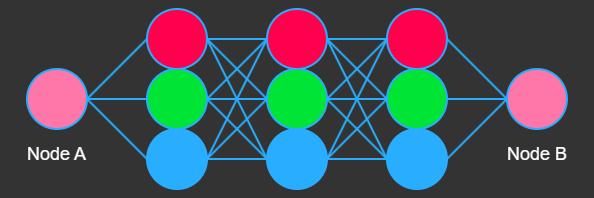

* The task for our agent is to select a certain routing schedule for packages going from Node A to Node B, where a package is sent one at a time via connections in the network and through intermediate nodes (red, green and blue). The traversal through each edge incurs a random latency cost and the goal is to minimize the total expected latency incurred for sending a package.  

* We can model the problem as a bandit problem by mapping each route to a ternary string, e.g. RRB for traversing through a Red, Red and then Blue node. Since there are $3^3 = 27$ different routes to take, our bandit is a 27-armed bandit with unknown total latency distributions for each arm. 
* For our application, we create the `Bandit` by running the code in the following cell. With the mapping $R\to 0$, $G\to 1$, $B\to 2$ and converted ternary string $(x_2 x_1 x_0)$, $x_i \in \{0,1,2\}$, we have the corresponding arm index $k$ by the base-10 integer representation: $$k =  x_2 3^2 +  x_1 3+ x_0 3^0$$  

In [33]:
# Create the network bandit by running this cell
import lzma

loc = dict()
exec(
    lzma.decompress(
        bytes.fromhex(
            "fd377a585a000004e6d6b4460200210116000000742fe5a3e0088704e95d00349b4a67b8523c73e564dccd09aeddf6229e5bac5e4783e82d135146a88b29f51a8d35d8a77b550742348ceed2f1f1e95b6fcedf205a40087ed70d2c483e5f72bff2cd8da636bebf5f448b1626b8aa5d556b5c52aec5e7cc0ab2697f45c8c4654aa7605e6a8562be4b59e452260f4daddae299cbcf79d5e0923bbbf3185cef5ea09294189e3e3ec8eabc887b09d49b2871eff1d85286cc4ef3242d236bf157fd84778ca2718252a7bd46113762e40c2b95ff246852f11c309f98d0df31a8fb139f2c7dbe0eeb1f6df1644f07eb62c56105ed778320d3c03b12359a1681b8c80175b856d45c118b4dea5fabc2e0408399d8ac418e6578bc9d52ce62f8bf131c3660970e133503dd72c4781fff410dcc286a3619b2ad62ce9f60a22bc41e1a2744558f55d19f0f4bedebda3c3c24a5681cfb9b237c330c1d045fa49db58c09b63b5c721a89336c69de5a6bbb92d451bdd10fc03c859fadc02751a3cca8eabf3dccf428f69c68d397da01949185ecf3dc0cf158680f64e5a5a1abcb21e4b6296cc53f324dd3e868da0dd4d7aa2690a1b24f5df7c31fc0e81367f7b1dc576f7ce5ff2547a9f5bfbcb9c407fcb3596fd3898a9e816f6822cb7e2ef43068517b6ac7f43da13c6cc29af67cac1c5b795cd18fb8fc9014f53c3ed7b2bc52f55a4ad709a6951a8a62bab8255b82ca8cdd1e6b6de1f66dc871ca210fdbbf275f0fe1f91799c3758feb14d12b81a728e8593004b9d7845030f4888f3eeee7a5cdfd04350a00a93279cc764378a56666c5e4d51c3123a6032422fd759c3ef3a8057745da68f1cfb0ebb7fd768d79b435f0919d35d2371446beadbd48f322a4bbbdde02c53ee9029387d40262aceffc6332b4dac09ac3bfb14fd289ad8b5087ebb83791d2f144baece90bbbc5328fd9b7086c7db165bc66f3455ff966c95e2fe10928c66394e482efd99680a53f46bd1fa2366abc5ec6921ff4e5a4ff213f9d1995816fc61c43b3fd3391dd0d40ebbd42b8c1af2836579c4fd2139cce217db495e652208b00e00b380b727270250e9884dad013a9f408acda9bd7753046fd2a650ce593faf09b30d63a59cabe375851214d01b49d2b471bd299f378a037df1a20891c8947b50f62186a925258549d10bc67ccd8d613495708afd7e3fd652e5fae4c244d688c0234a28876de14a67512d5821021977ff0f7170b765814a55a645f91cfd3fbcf25489a8d5d44563c9d0680eb230e5b335c884a7917b38c39feade0025abaadd4c40f3ce682cec7f8d68bbacb50f64486f007d7d2a0947102495511be96dbf5bc887fe206d07e23f7bffa548adfff6f49290316bb14ace2629200b5f7354a32156e840434fc55ee5c4918d8bc7bd959900248243155bf33cb0969a089b83d51ce329f9d9cab2505615fd9be32f9a2aef7061964dcb1ec3259a89b64439460e4575d8d558d13f67fd73a929f97f36e048c2aae1a61dcebcc37e59259e8b36356ea3974fdbdf69bcfb060c6f30cee437a94883937bc4231e38051c90ff4d5ecafd22fa92bfe3e9e58da040e6140114c06cd48c8f921f54a05763b43ebfe1b70d887227e286f439bf8dba1d2bda7cbe407320af53cd6b327d27f63327a0372e9971eccf570383b850816b7949aa63f3e9cc786158f5b5450175b97a59d9f8d7d792f09287cdd695b9478722a0ee2a7f33a11c38d8a1d3f09f92433793bcfe1d3723ed4071f9408c8b6217b2aa706783b0ab0fbaa66405c7f0b52dd0c16dc518067dd3f77044e1f580b47c3000000000056d709409aa2fbf80001850a88110000841e91f2b1c467fb020000000004595a"
        )
    ),
    globals(),
    loc,
)
netbandit: Bandit = loc["_nbit"]

___

### Problem 7. Solving the Network Bandit
In this final problem we want to solve the supplied `Bandit` and present our estimation of the optimal route. We've been asked to provide a learner which is supposed to function *online*, i.e., on-the-fly. So we need our algorithm to also quickly hone in on a good estimation without incurring too much cost in the learning phase. 

Our tasks are the following:
1. Note that the supplied bandit returns costs which we want to minimize in expectation, whereas your previous algorithms try to maximize rewards. What is the clear modification that needs to be made? 
2. Try to solve the bandit by using any of the previous algorithms in this laboration. With a suitable number of runs, tune your chosen algorithm over $T=200$ by optimizing the hyperparameter value against an estimate of the average accumulated cost: $$\mathbb{E}\left[\sum_{t=1}^T R_t\right].$$
**Hint:** Make a scatter plot of different parameter values versus the estimate.
3. By repeating the experiment for your best solution a number of times, present a graph of the average learning trajectory over 200 packages in terms of cost per package (not accumulated). 
4. Do you think you can estimate $\mu^*$? Present a ternary string (in R,G,B) for your estimation of the optimal route.

In [34]:
# Create a negative UCB to minimize reward/cost (LCB) and simulation harness...
def lcb(env: Bandit, horizon: int, c: float):
    """
    UCB-style algorithm.
    """
    K = env.K()
    T = horizon

    rewards = np.empty(T, dtype=float)
    actions = np.empty(T, dtype=int)

    counts = np.zeros(K, dtype=int)
    sums   = np.zeros(K, dtype=float)

    for t in range(T):
        if t < K:
            k = t
        else:
            means = sums / counts
            lower = c * np.sqrt(np.log(t + 1) / counts)
            k = int(np.argmin(means - lower))

        r = env.pull(k)
        rewards[t] = r
        actions[t] = int(np.argmin(sums / counts - c * np.sqrt(np.log(t + 1) / counts)))
        counts[k] += 1
        sums[k]   += r

    emp_means = sums / counts
    return rewards, actions, emp_means

def run_experiment_lcb(bandit, horizon=1000, cs=None,
                       n_runs=2000, seed=0, mu_star=None, k_star=None):
    if cs is None:
        cs = {"c=0.5": 0.5, "c=1": 1.0, "c=sqrt2": np.sqrt(2),
              "c=2": 2.0, "c=5": 5.0}

    results = {}
    for label, c in cs.items():
        regret_acc = np.zeros(horizon)
        opt_acc    = np.zeros(horizon)

        for run in tqdm.tqdm(range(n_runs), desc=label):
            np.random.seed(seed + run)
            rewards, actions, _ = lcb(bandit, horizon, c)

            regret_acc += np.cumsum(rewards)
            opt_acc    += (actions == k_star).astype(float)

        results[label] = {
            "avg_regret": regret_acc / n_runs,
            "avg_opt"   : opt_acc    / n_runs,
        }
    return results

### Solution

c=0.01:   0%|          | 0/2 [00:00<?, ?it/s]C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\3246254209.py:25: RuntimeWarning: invalid value encountered in divide
  actions[t] = int(np.argmin(sums / counts - c * np.sqrt(np.log(t + 1) / counts)))
C:\Users\kalle\AppData\Local\Temp\ipykernel_31084\3246254209.py:25: RuntimeWarning: divide by zero encountered in divide
  actions[t] = int(np.argmin(sums / counts - c * np.sqrt(np.log(t + 1) / counts)))
c=√2: 100%|██████████| 2/2 [00:00<00:00, 307.03it/s]


<Figure size 640x480 with 0 Axes>

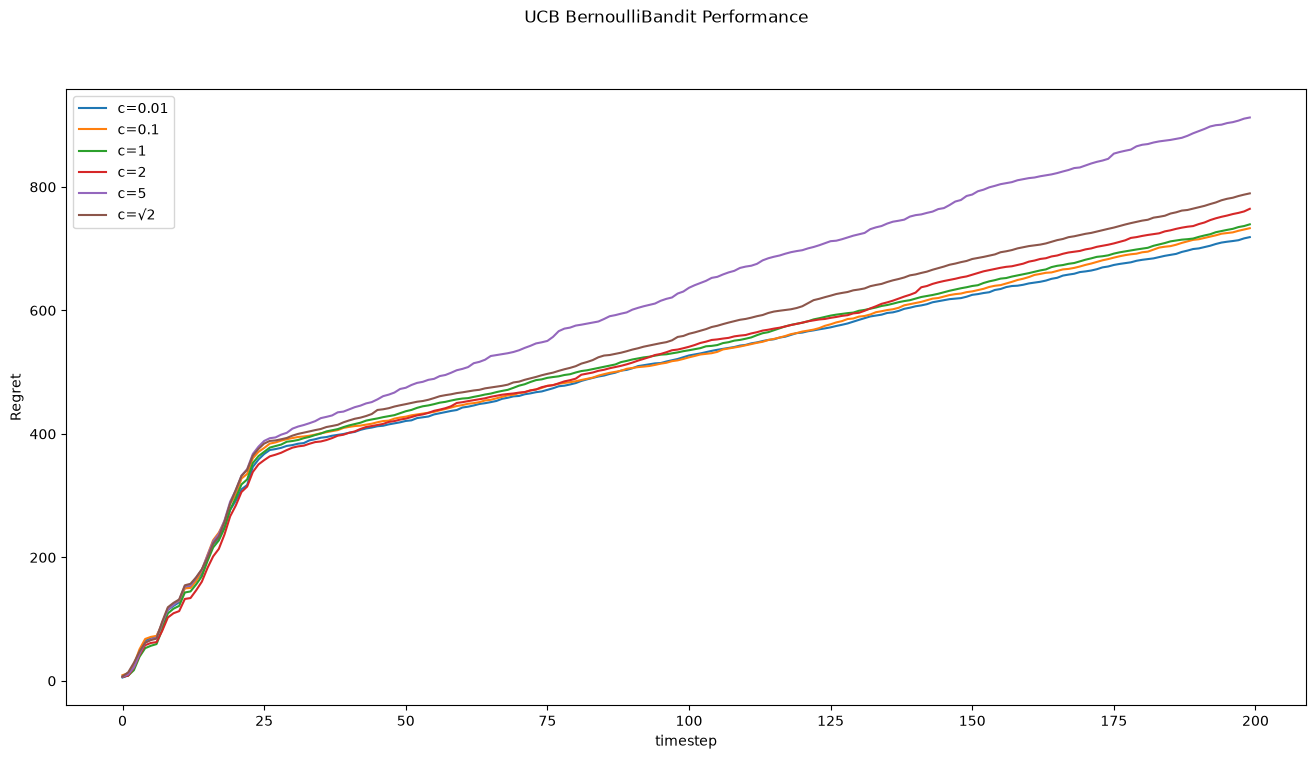

In [ ]:
# UCB NetworkBandit...

horizon = 200
n_runs = 2000

cs = {
    "c=0.01":   0.01,
    "c=0.1":    0.1,
    "c=1":      1,
    "c=2":      2,
    "c=5":      5,
    "c=√2":     np.sqrt(2),
}

results = run_experiment_lcb(netbandit, horizon=horizon, cs=cs, n_runs=n_runs, seed=0)

plt.figure()
fig, axes = plt.subplots(1, 1, figsize=[16, 8])
plt.suptitle("UCB BernoulliBandit Performance")
plt.xlabel("timestep")
plt.ylabel("Regret")

for label in results.keys():
    plt.plot(np.arange(0, horizon), results[label]["avg_regret"], label=label)

plt.legend()
plt.show()

___